# I. Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **_Delphino Chew_** | _delphinochew@gmail.com_ | **_Credit Card Fraud Detection_** |

# II. Notebook Target Definition

_The target variable is Class, which indicates whether a credit card transaction is legitimate (0) or fraudulent (1). Feature engineering will focus on creating or transforming predictor variables to improve the model's ability to distinguish between the two classes._

# III. Notebook Setup

## III.A. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

## III.B. Import Data

In [2]:
X_train = pd.read_pickle('../../data/processed/X_train.pkl')
X_test = pd.read_pickle('../../data/processed/X_test.pkl')
y_train = pd.read_pickle('../../data/processed/y_train.pkl')
y_test = pd.read_pickle('../../data/processed/y_test.pkl')

In [3]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,144549.0,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,3.496508
134253,80716.0,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,2.078191
186465,127116.0,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,2.769459
149493,91342.0,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,2.906901
18461,29522.0,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,3.218876


In [4]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86568,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,2.525729
251557,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,1.078410
20232,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,4.524827
68952,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,5.433722
191852,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,0.879627


In [5]:
y_train.head()

226238    0
134253    0
186465    0
149493    0
18461     0
Name: Class, dtype: int64

In [6]:
y_test.head()

86568     0
251557    0
20232     0
68952     0
191852    0
Name: Class, dtype: int64

# IV. Feature Engineering

## IV.A. Data Shape Inspection

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (226980, 30)
X_test: (56746, 30)


In [8]:
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train: (226980,)
y_test: (56746,)


## IV.B. Data Information Inspection

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 226980 entries, 226238 to 67057
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    226980 non-null  float64
 1   V1      226980 non-null  float64
 2   V2      226980 non-null  float64
 3   V3      226980 non-null  float64
 4   V4      226980 non-null  float64
 5   V5      226980 non-null  float64
 6   V6      226980 non-null  float64
 7   V7      226980 non-null  float64
 8   V8      226980 non-null  float64
 9   V9      226980 non-null  float64
 10  V10     226980 non-null  float64
 11  V11     226980 non-null  float64
 12  V12     226980 non-null  float64
 13  V13     226980 non-null  float64
 14  V14     226980 non-null  float64
 15  V15     226980 non-null  float64
 16  V16     226980 non-null  float64
 17  V17     226980 non-null  float64
 18  V18     226980 non-null  float64
 19  V19     226980 non-null  float64
 20  V20     226980 non-null  float64
 21  V21     226

In [10]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56746 entries, 86568 to 8267
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    56746 non-null  float64
 1   V1      56746 non-null  float64
 2   V2      56746 non-null  float64
 3   V3      56746 non-null  float64
 4   V4      56746 non-null  float64
 5   V5      56746 non-null  float64
 6   V6      56746 non-null  float64
 7   V7      56746 non-null  float64
 8   V8      56746 non-null  float64
 9   V9      56746 non-null  float64
 10  V10     56746 non-null  float64
 11  V11     56746 non-null  float64
 12  V12     56746 non-null  float64
 13  V13     56746 non-null  float64
 14  V14     56746 non-null  float64
 15  V15     56746 non-null  float64
 16  V16     56746 non-null  float64
 17  V17     56746 non-null  float64
 18  V18     56746 non-null  float64
 19  V19     56746 non-null  float64
 20  V20     56746 non-null  float64
 21  V21     56746 non-null  float64
 22  

In [11]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 226980 entries, 226238 to 67057
Series name: Class
Non-Null Count   Dtype
--------------   -----
226980 non-null  int64
dtypes: int64(1)
memory usage: 3.5 MB


In [12]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 56746 entries, 86568 to 8267
Series name: Class
Non-Null Count  Dtype
--------------  -----
56746 non-null  int64
dtypes: int64(1)
memory usage: 886.7 KB


## IV.D. Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [14]:
print(X_train_scaled.describe().loc[["mean", "std"]])

              Time            V1            V2            V3            V4  \
mean -1.518880e-16  1.627818e-18 -1.220864e-17  8.170396e-18 -2.657727e-17   
std   1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

                V5            V6            V7            V8            V9  \
mean  1.029908e-17 -1.139473e-17 -8.827784e-18 -1.095647e-19  7.763442e-18   
std   1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

      ...           V20           V21           V22           V23  \
mean  ... -7.137358e-18  2.504336e-18 -4.507805e-18  3.599983e-18   
std   ...  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

               V24           V25           V26           V27           V28  \
mean -6.933880e-18  3.944329e-18 -1.790600e-17  2.754770e-18  2.629553e-18   
std   1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

            Amount  
mean  1.792635e-16  
std   1.000002e+00  

[2 rows x 30 columns]


## IV.E. Final Feature Inspection

In [15]:
print("Training features:")
print(X_train_scaled.shape)
print(X_train_scaled.columns.tolist())

print("\nTesting features:")
print(X_test_scaled.shape)
print(X_test_scaled.columns.tolist())

Training features:
(226980, 30)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Testing features:
(56746, 30)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [21]:
print("Missing values in X_train_scaled:", X_train_scaled.isnull().sum().sum())
print("Missing values in X_test_scaled:", X_test_scaled.isnull().sum().sum())

print("Infinite values in X_train_scaled:", np.isinf(X_train_scaled).sum().sum())
print("Infinite values in X_test_scaled:", np.isinf(X_test_scaled).sum().sum())

Missing values in X_train_scaled: 0
Missing values in X_test_scaled: 0
Infinite values in X_train_scaled: 0
Infinite values in X_test_scaled: 0


# V. Feature Selection

## V.A. Feature Optimal Binning

In [22]:
mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=42
)

mi_table = pd.DataFrame({
    "variables": X_train_scaled.columns,
    "mutual_information": mi_scores
})

mi_table = mi_table.sort_values(
    by="mutual_information",
    ascending=False,
    ignore_index=True
)

mi_table

,variables,mutual_information
0,V17,0.008013
1,V14,0.007946
2,V10,0.007320
3,V12,0.007315
4,V11,0.006577
5,V16,0.005876
6,V3,0.004671
7,V4,0.004623
8,V9,0.004051
9,V18,0.003992


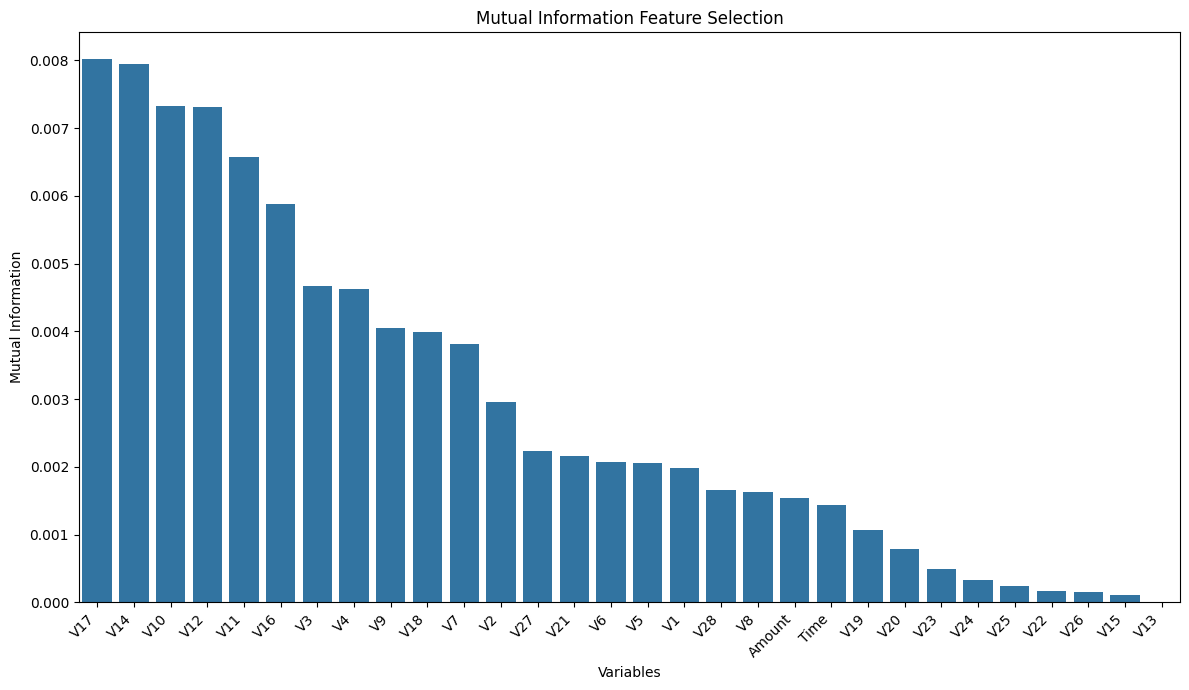

In [23]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=mi_table,
    x="variables",
    y="mutual_information"
)

plt.title("Mutual Information Feature Selection")
plt.xlabel("Variables")
plt.ylabel("Mutual Information")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## V.B. Export Data

In [24]:
X_train_scaled.to_pickle('../../data/processed/X_train_fe.pkl')
X_test_scaled.to_pickle('../../data/processed/X_test_fe.pkl')

y_train.to_pickle('../../data/processed/y_train_fe.pkl')
y_test.to_pickle('../../data/processed/y_test_fe.pkl')